In this worked notebook file,the Support Vector Regression algorithm is applied to a dataset called steel.

The dependent variable that we are trying to predict is tensile_strength, which is a numerical value

In [2]:
import pandas as pd

# details for steel dataset
independent_cols = ["normalising_temperature", "tempering_temperature", "percent_silicon", "percent_chromium", "percent_copper", "percent_nickel", "percent_sulphur", "percent_carbon", "percent_manganese"]

dependent_col = "tensile_strength"

# Here we load our dataset in from file using the pandas library
df = pd.read_csv("steel.csv")
print("Data Shape:\n", df.shape)
print("Data Description:\n", df.describe())

Data Shape:
 (553, 10)
Data Description:
        normalising_temperature  tempering_temperature  percent_silicon  \
count               553.000000             553.000000       553.000000   
mean                478.205222             752.124774         0.063890   
std                 162.317845             259.220817         0.080655   
min                 178.500000             225.000000         0.000000   
25%                 382.987500             550.000000         0.000000   
50%                 465.850000             900.000000         0.000000   
75%                 570.500000             900.000000         0.129800   
max                 945.000000             950.000000         0.359400   

       percent_chromium  percent_copper  percent_nickel  percent_sulphur  \
count        553.000000      553.000000      553.000000       553.000000   
mean           1.277492        0.784018        0.972592         0.059302   
std            0.260280        0.068589        0.074270        

In [3]:
#prepare features (X) and target (Y)
X = df.drop(columns=[dependent_col])
y = df[dependent_col]
print("Features:\n", X.head())
print("Target:\n", y.head())

Features:
    normalising_temperature  tempering_temperature  percent_silicon  \
0                  178.500                    275           0.1530   
1                  178.500                    950           0.1530   
2                  178.500                    375           0.1530   
3                  178.500                    900           0.1530   
4                  189.525                    900           0.1624   

   percent_chromium  percent_copper  percent_nickel  percent_sulphur  \
0          0.970575           0.942          0.8870              0.0   
1          1.212726           0.942          0.8870              0.0   
2          1.621165           0.942          0.8870              0.0   
3          0.809989           0.942          0.8870              0.0   
4          1.036229           0.849          0.9382              0.0   

   percent_carbon  percent_manganese  
0           1.920                0.0  
1           1.920                0.0  
2           1.920 

In [5]:
from sklearn.model_selection import train_test_split
# Split data into training and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(442, 9)
(442,)
(111, 9)
(111,)


10-fold cross validation on training data

In [6]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np

kf = KFold(n_splits=10, shuffle=True, random_state=42)
model = RandomForestRegressor()

# Scores
mae_scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_absolute_error', cv=kf)
r2_scores = cross_val_score(model, X_train, y_train, scoring='r2', cv=kf)

print("SVR Mean MAE:", -np.mean(mae_scores))
print("SVR Mean r2:", np.mean(r2_scores))

SVR Mean MAE: 25.061706029116646
SVR Mean r2: 0.859183449871239


No hyperparameter tuning, default skikit-learn implementation

In [8]:
from sklearn import metrics

model.fit(X_train, y_train)

# compute predictions for training and test sets
predictions_training_default = model.predict(X_train)
predictions_test_default = model.predict(X_test)

# Evaluate
mae_train_default = metrics.mean_absolute_error(y_train, predictions_training_default)
mae_test_default = metrics.mean_absolute_error(y_test, predictions_test_default)
r2_train_default = metrics.r2_score(y_train, predictions_training_default)
r2_test_default = metrics.r2_score(y_test, predictions_test_default)

print("Training MAE:", mae_train_default)
print("Test MAE:", mae_test_default)
print("Training R²:", r2_train_default)
print("Test R²:", r2_test_default)

Training MAE: 8.915160212965148
Test MAE: 24.102619774530655
Training R²: 0.981419200598758
Test R²: 0.898155908935529


Now we test the effect of hyperparameter tuning on the SVM model. We will use the RBF kernel and vary the values of C and gamma to see how they affect the accuracy of the model on both the training and test datasets.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650],
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=kf,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
#find best model
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation MAE:", -grid_search.best_score_)

#evaluate best model on training and test sets
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

#compute metrics
mae_train = metrics.mean_absolute_error(y_train, train_pred)
mae_test = metrics.mean_absolute_error(y_test, test_pred)
r2_train = metrics.r2_score(y_train, train_pred)
r2_test = metrics.r2_score(y_test, test_pred)

print("Training MSE:", mae_train)
print("Test MSE:", mae_test)
print("Training R²:", r2_train)
print("Test R²:", r2_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best Parameters: {'max_depth': 20, 'n_estimators': 50}
Best Cross Validation MAE: 24.61483012024624
Training MSE: 9.173170047945232
Test MSE: 25.878175367445046
Training R²: 0.9802776031534357
Test R²: 0.8850812301088877


Visualising the predictions of the Default vs Tuned model.

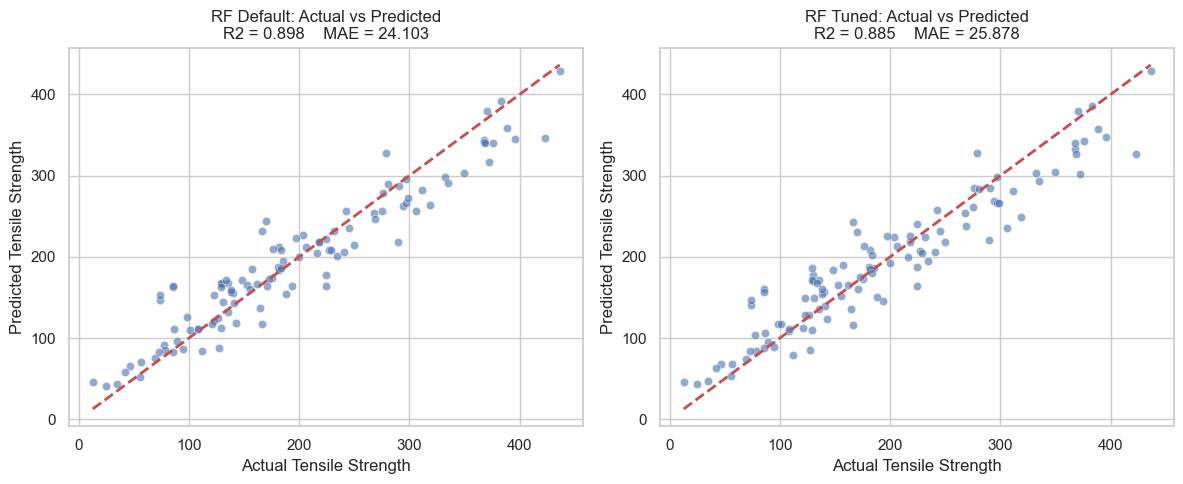

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))

# Default model
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=predictions_test_default, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel("Actual Tensile Strength")
plt.ylabel("Predicted Tensile Strength")
plt.title(f"RF Default: Actual vs Predicted\nR2 = {r2_test_default:.3f}    MAE = {mae_test_default:.3f}")

# Tuned model
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Tensile Strength")
plt.ylabel("Predicted Tensile Strength")
plt.title(f"RF Tuned: Actual vs Predicted\nR2 = {r2_test:.3f}    MAE = {mae_test:.3f}")

plt.tight_layout()
plt.show()

Visualising the difference in prediction errors

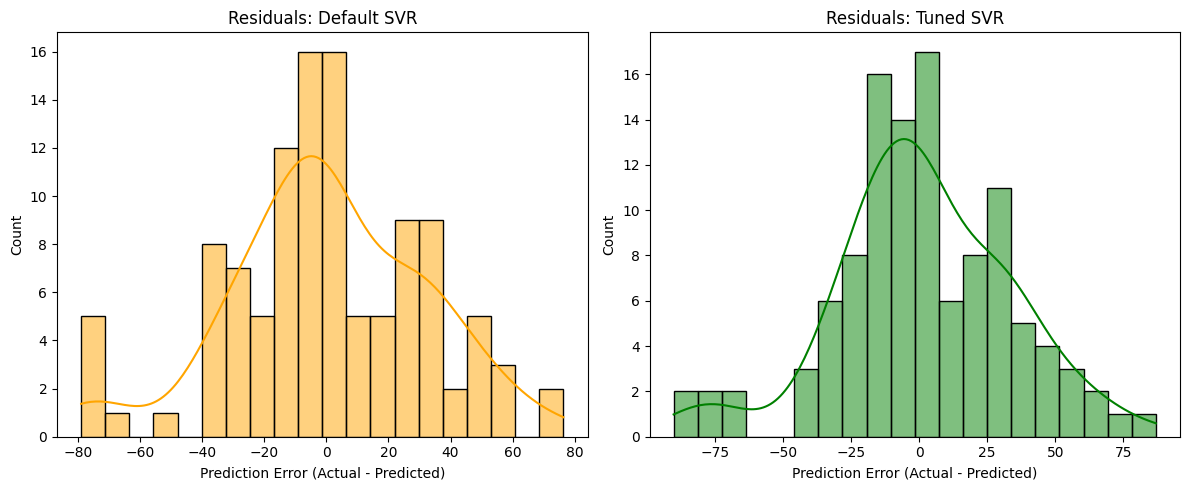

In [17]:
residuals_default = y_test - predictions_test_default
residuals_tuned = y_test - test_pred

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_default, kde=True, bins=20, color='orange')
plt.title("Residuals: Default RF")
plt.xlabel("Prediction Error (Actual - Predicted)")

plt.subplot(1, 2, 2)
sns.histplot(residuals_tuned, kde=True, bins=20, color='green')
plt.title("Residuals: Tuned RF")
plt.xlabel("Prediction Error (Actual - Predicted)")

plt.tight_layout()
plt.show()

Hyperparameter effect

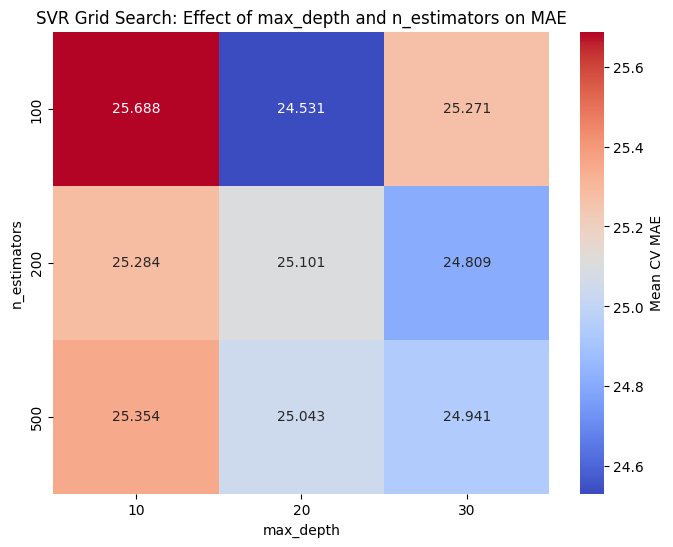

In [21]:
results = grid_search.cv_results_
df_results = pd.DataFrame(results)

# Extract relevant data
pivot_table = df_results.pivot_table(
    values='mean_test_score',
    index='param_n_estimators',
    columns='param_max_depth'
)

# Convert to positive MAE
pivot_table = -pivot_table

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label': 'Mean CV MAE'})
plt.title("SVR Grid Search: Effect of max_depth and n_estimators on MAE")
plt.xlabel("max_depth")
plt.ylabel("n_estimators")
plt.show()